# Datensatz pdfqa_pdfQA

https://arxiv.org/abs/2601.02285

Durchführung einer Analyse des Datensatzes pdfqq_pdfQA.

Der Datensatz besteht aus einer Zusammenstellung von 9 separaten Datensätzen mit Veröffentlichungen von Unternehmen und öffentlichen Einrichtungen (Finanz- und Klimaschutz/Nachhaltigkeits-Berichte), Wikipedia-Artikeln, wissenschaftlichen Veröffentlichungen der Plattform arxiv.org sowie diversen allgemeinen Themen. Der Datensatz ist auf zwei Reposities pdfqa/pdfQA-Benchmark\footnote{\url{https://huggingface.co/datasets/pdfqa/pdfQA-Benchmark}} und pdfqa/pdfQA-Annotations\footnote{\url{https://huggingface.co/datasets/pdfqa/pdfQA-Annotations}}) verteilt.

Das Repository pdfqa/pdfQA-Benchmark beinhaltet die einzelnen Abschnitte der Dokumente in strukturierter Form sowie die Namen der dazugehörigen PDF-Dateien. Das Repository pdfqa/pdfQA-Annotations enthälte Paare mit Fragen und dazuhörigen Referenz-Antworten sowie den Abschnitt bzw. die Abschnitte eines Dokuments, auf welche sich diese beziehen.

Die Informationen werden im JSON-Format als einzelne Dateien für jedes PDF-Dokument zur Verfügung gestellt.

**Climate Finance Bench**  
https://github.com/Pladifes/climate_finance_bench  
https://arxiv.org/pdf/2505.22752

**ClimRetrieve**  
https://github.com/tobischimanski/ClimRetrieve  
https://arxiv.org/pdf/2406.09818

**FeTaQA**  
https://github.com/Yale-LILY/FeTaQA  
https://arxiv.org/pdf/2104.00369

**FinQA**  
https://github.com/czyssrs/FinQA  
https://arxiv.org/pdf/2109.00122

**FinanceBench**  
https://github.com/patronus-ai/financebench  
https://arxiv.org/pdf/2311.11944

**NaturalQuestions**  
https://aclanthology.org/Q19-1026.pdf

**PaperTab**  
https://github.com/qinchuanhui/uda-benchmark  
https://arxiv.org/pdf/2406.15187

**PaperText**

**Tat-QA**  
https://github.com/NExTplusplus/TAT-QA  
https://aclanthology.org/2021.acl-long.254.pdf

## Setup

### Pakete laden

In [1]:
import glob
import json
import urllib

import numpy as np
import pandas as pd

from scipy import stats

from plotly.subplots import make_subplots
import plotly.graph_objects as go

from util.px import PX

### Variablen+Funktionen

In [2]:
# Pfad zu Dateien des Datensatz
path = 'pdfqa_pdfQA/pdfQA-Annotations/real-pdfQA/'

## Daten laden

JSON-Dateien aller PDF-Dokumente einlesen

Fragen,Antworten und Abschnitten in Dictionary einlesen und Pandas-Dataframe erstellen

In [3]:
#print(glob.glob(path + '*'))
#pd.set_option('display.max_colwidth', None)

In [4]:
# Dictionary für Daten
data = {"question":[], "answer":[], "sources":[], "num_sources_used":[], "file_name":[], "file_path":[]}

# Über alle Verzeichnisse mit Datensätzen im Haupt-Verzeichnis iterieren
for folder in glob.glob(f'{path}*'):
    # Über alle Dateien im Verzeichnis eines Datensatz iterieren
    for file in glob.glob(f'{folder}/*'):
        # Datei öffnen und als JSON-Object laden
        try:
            f = open(file, 'r', encoding='utf-8')
            file_data = json.load(f)
            f.close()
        except Exception as e:
            print(f"Exception occurred: {e}")
            continue

        # Über alle Einträge der Liste des JSON-Objekts iterieren
        for entry in file_data:
            data['question'].append(entry['question'])
            data['answer'].append(entry['answer'])
            data['sources'].append(entry['sources'])
            data['num_sources_used'].append(entry['num_sources_used'])
            data['file_name'].append(entry['file_name'])
            data['file_path'].append(folder[folder.rfind('\\') + 1:])#file.replace('\\', '/')

# Pandas Dataframe aus Dictionary mit Informationen erstellen
pdfqa = pd.DataFrame.from_dict(data)

# Datentypen convertieren
pdfqa = pdfqa.convert_dtypes()

In [5]:
print(pdfqa.info())

<class 'pandas.DataFrame'>
RangeIndex: 2037 entries, 0 to 2036
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   question          2037 non-null   string
 1   answer            2037 non-null   string
 2   sources           2037 non-null   object
 3   num_sources_used  2037 non-null   Int64 
 4   file_name         2037 non-null   string
 5   file_path         2037 non-null   string
dtypes: Int64(1), object(1), string(4)
memory usage: 361.8+ KB
None


In [6]:
pdfqa

,question,answer,sources,num_sources_used,file_name,file_path
0,According to the company's Disclosure from FY2...,According to the company's statement for fisca...,[doc1{Governance indicators\nBUSINESS CONDUCT ...,2,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench
1,Does the company operate in a high emitting se...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench
2,What is the company's carbon intensity (in TCO...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench
3,Does the company disclose a Transition Plan fo...,LVMH does not explicitly disclose a formal Tra...,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench
4,What is the total carbon footprint of the comp...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench
...,...,...,...,...,...,...
2032,How does the Group manage its liquidity requir...,The Group manages its liquidity requirements w...,[104\n\n\n\nNotes to the Consolidated Financia...,1,Woolworths-Limited_2019,Tat-QA
2033,What were the organisations the company purcha...,Greenview EMS,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA
2034,What is the percentage change in goodwill from...,1142.18,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA
2035,Which year had the highest Net cash provided b...,2017,[_**Sources and Uses of Cash**_\n\n\n**Years E...,1,zix-corporation_2019,Tat-QA


## Explorativen Datenanalyse

Prüfung der Qualität (Eindeutigkeit, Vollständigkeit etc.) für Fragen, Antworten und Quellen/Abschnitte.

Berechnung statistischer Kennzahlen zu Fragen, Antworten, Abschnitten (Gesamtzahl, Eindeutige Werte, Häufigkeiten etc.) für gesamten Datensatz und Teil-Datensätze sowie Merkmale (Anzahl Zeichen/Wörter)

In [7]:
print(f'Anzahl Datensätze: {pdfqa["file_path"].unique().shape[0]}')
print(f'Gesamtzahl Samples (Fragen+Antworten): {pdfqa.shape[0]}')
print(f'Anzahl eindeutiger Fragen: {pdfqa["question"].unique().shape[0]}')
print(f'Anzahl eindeutiger Antworten: {pdfqa["answer"].unique().shape[0]}')
#print(f'Anzahl Fragen-Referenzen: {qrels.shape[0]}')
print(f'Eindeutige Anzahl referenzierter Dokumente: {pdfqa["file_name"].unique().shape[0]}')

Anzahl Datensätze: 9
Gesamtzahl Samples (Fragen+Antworten): 2037
Anzahl eindeutiger Fragen: 1948
Anzahl eindeutiger Antworten: 1744
Eindeutige Anzahl referenzierter Dokumente: 512


In [8]:
# fehlende Werte prüfen
#pdfqa.isna().any().any()
pdfqa.isna().any().any() or pdfqa.eq("").any().any()

np.False_

In [9]:
# Absolute Häufigkeiten der einzelnen Fragen (Top-Ten)
pdfqa['question'].value_counts().reset_index().iloc[:10]

,question,count
0,Does the company operate in a high emitting se...,14
1,According to the company's Disclosure from FY2...,9
2,Has the company identified significant decarbo...,6
3,Does the company encourage downstream partners...,6
4,What is the company's carbon intensity (in TCO...,5
5,What is the total carbon footprint of the comp...,5
6,Does the company have a decarbonization trajec...,4
7,"What is the scope 1, 2 and 3 emissions (in TCO...",4
8,Does the company report the methodology used t...,4
9,What drove carbon intensity change as of the F...,3


In [10]:
# Absolute Häufigkeiten der einzelnen Antworten (Top-Ten)
pdfqa['answer'].value_counts().reset_index().iloc[:10]

,answer,count
0,2,33
1,Not available in the retrieved information.,28
2,no,24
3,1,22
4,2019,20
5,2018,15
6,No,13
7,Not available in the retrieved information,12
8,3,9
9,2017,7


Der Datensatz umfasst insgesamt 2037 Beobachtungen (Fragen+Antworten), welche sich auf die 9 Datensätze verteilen. 1948 der insgesamt 2037 Fragen und 1744 der Antworten sind eindeutig. Die Fragen beziehen sich auf insgesamt 512 eindeutige Dokumente. Unter den mehrfach auftretenden Fragen kommt "Does the company operate in a high emitting sector as of FY2023?" mit einer Anzahl von 14 auf häufigsten vor. Die Antwort "2" tritt mit einer Anzahl von 33 am häufigsten auf, gefolgt von der Antwort "Not available in the retrieved information." mit einer Anzahl von 28.

### Anzahl Fragen+Antworten/Dokument

In [11]:
# Absolute Häufigkeiten der referenzierten Dokumente (Top-Ten)
pdfqa_file_name_value_counts = pdfqa['file_name'].value_counts()
pdfqa_file_name_value_counts.reset_index().iloc[:10]

,file_name,count
0,jabil-circuit-inc_2019,56
1,advanced-energy_2019,52
2,sykes-enterprises-incorporated_2019,43
3,aci-worldwide-inc_2019,41
4,american-tower-corporation_2019,40
5,alarmcom-holdings-inc_2019,34
6,cogeco-inc_2019,34
7,vmware-inc_2019,33
8,plexus-corp_2019,32
9,cts-corporation_2019,30


In [12]:
print(f'Duchschnittliche Anzahl Fragen pro Dokument:{np.mean(pdfqa_file_name_value_counts.values)}')

Duchschnittliche Anzahl Fragen pro Dokument:3.978515625


Auf das Dokument "jabil-circuit-inc_2019" beziehen sich mit einer Anzahl von 56 die meisten Fragen, gefolgt von advanced-energy_2019 mit einer Anzahl von 52. Durchschnittlich beziehen sich auf ein Dokument weniger als 4 Fragen.

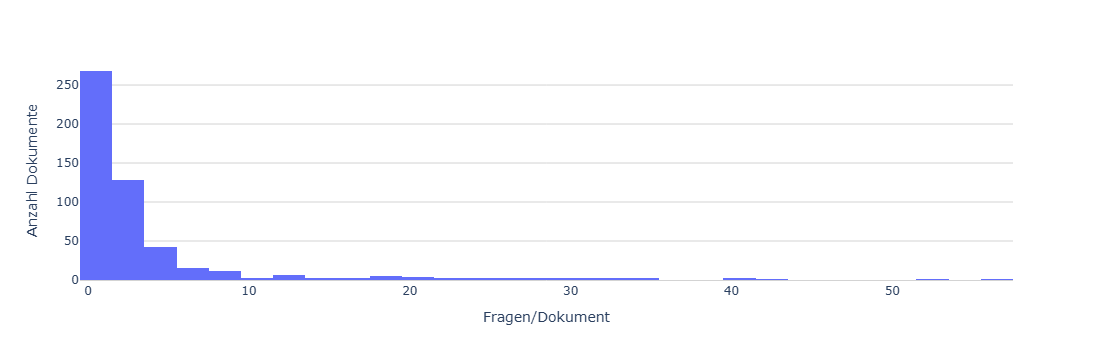

In [13]:
PX.hist(pdfqa_file_name_value_counts.values, xaxes = {'title': 'Fragen/Dokument'}, yaxes = {'title': 'Anzahl Dokumente'}, width=900)

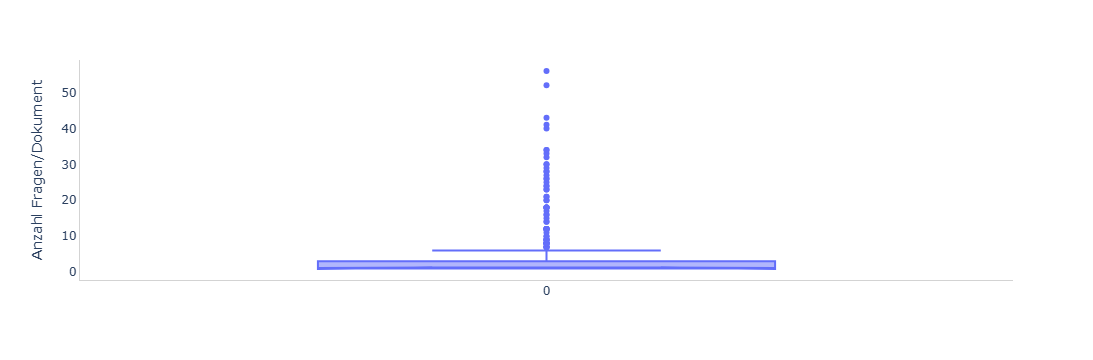

In [14]:
PX.box(pdfqa_file_name_value_counts.values, xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Fragen/Dokument'}, width=450)

Die insgesamt 2037 Fragen+Antworten des Datensatzes beziehen sich auf 512 eindeutige Dokumente. Auf 268 der Dokumente, und damit mehr als die Hälfte, bezieht sich genau eine Frage. Im Maximum bezieht sich auf ein Dokument 56 Fragen.

### Anzahl Fragen+Antworten/Datensatz

In [15]:
# Absolute Häufigkeiten der Fragen+Antworten pro Datensatz
pdfqa_file_path_value_counts = pdfqa['file_path'].value_counts()

print(pdfqa_file_path_value_counts)

file_path
Tat-QA                 1369
FinQA                   393
PaperText                71
ClimateFinanceBench      68
FeTaQA                   67
ClimRetrieve             21
PaperTab                 19
NaturalQuestions         16
FinanceBench             13
Name: count, dtype: int64[pyarrow]


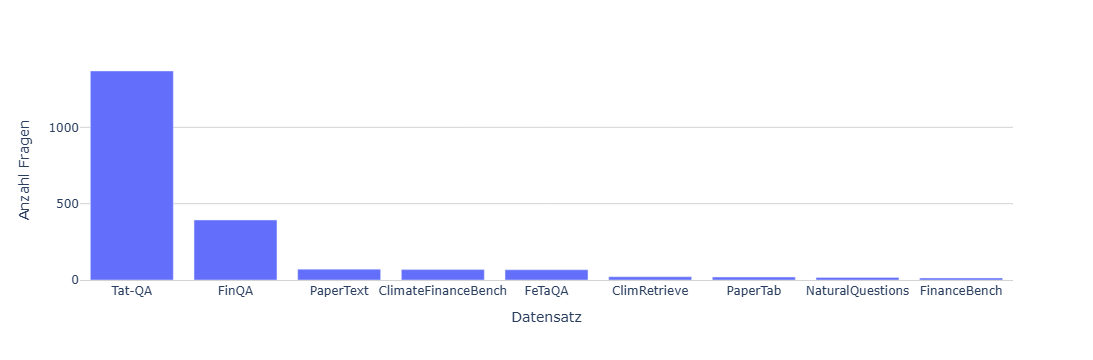

In [16]:
PX.bar(pd.DataFrame({'x': pdfqa_file_path_value_counts.index.tolist(), 'y': pdfqa_file_path_value_counts.values.tolist()}), xaxes = {'title': 'Datensatz'}, yaxes = {'title': 'Anzahl Fragen'})

Der Datensatz "Tat-QA" umfasst mit einer Anzahl von 1369 der insgesamt 2037 mehr als 2/3 (ca. 67%) der Fragen. Mit einer Anzahl von 13 umfasst der Datensatz "FinanceBench" die geringste Anzahl an Fragen.

### Anzahl Quellen/Frage

Auf welche Anzahl Quellen beziehen sich die Fragen?

In [17]:
# Absolute Häufigkeiten der Quellen pro Frage
pdfqa_num_sources_used_value_counts = pdfqa['num_sources_used'].value_counts()

pdfqa_num_sources_used_value_counts

num_sources_used
1     1868
2       90
0       43
3       15
4       12
5        3
8        2
11       1
7        1
18       1
13       1
Name: count, dtype: Int64

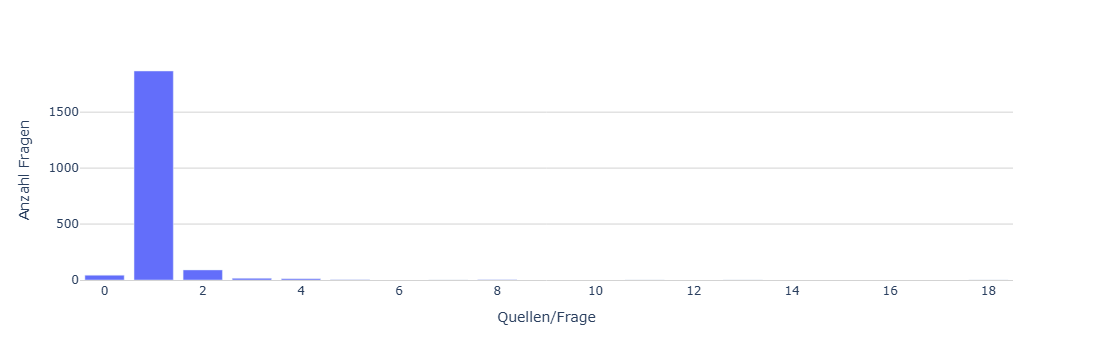

In [18]:
PX.bar(pd.DataFrame({"x": pdfqa_num_sources_used_value_counts.index.tolist(), "y": pdfqa_num_sources_used_value_counts.values.tolist()}), xaxes={'title':'Quellen/Frage'}, yaxes={'title': 'Anzahl Fragen'})

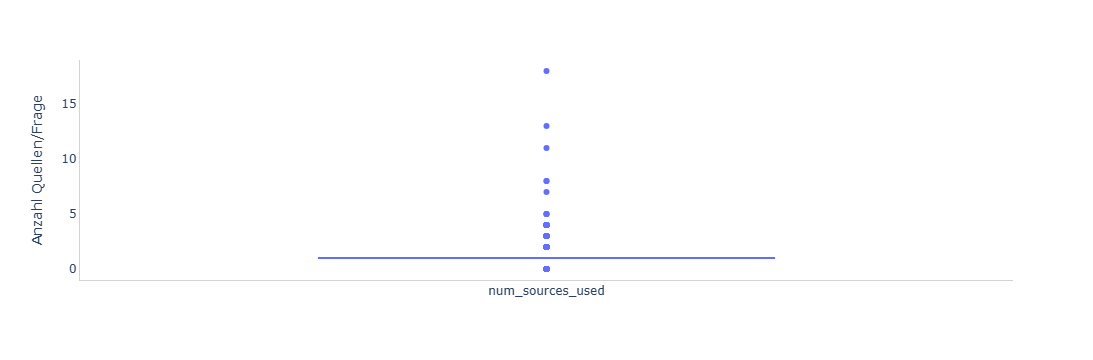

In [19]:
PX.box(pdfqa['num_sources_used'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Quellen/Frage'})

Mit 1868 der insgesamt 2037 Fragen, ca. 92%, bezieht sich der überwiegende Teil der Fragen auf eine Quelle. Im Maximum bezieht sich eine Frage auf 18 Quellen.

#### Anzahl Quellen/Frage/Datensatz

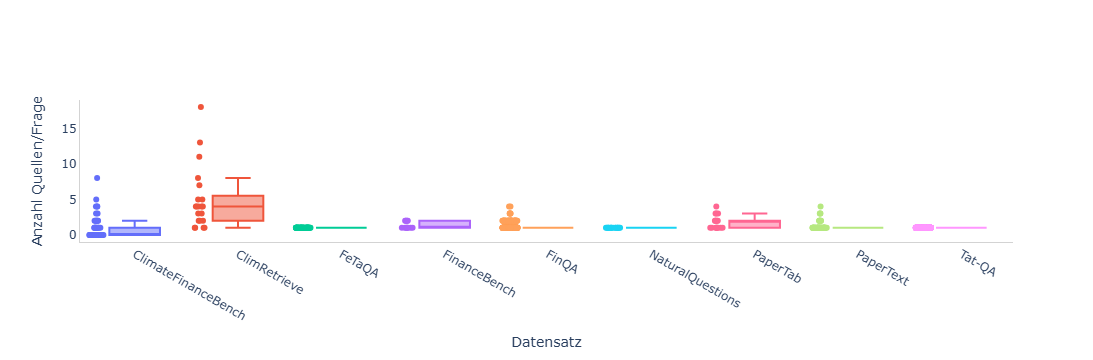

In [20]:
PX.box_multi(pdfqa, 'file_path', 'num_sources_used', xaxes={'title':'Datensatz'}, yaxes={'title':'Anzahl Quellen/Frage'})

In [21]:
# Absolute Häufigkeiten der Quellen pro Datensatz
pdfqa_file_path_group_num_sources_used = (
    pdfqa.astype({'num_sources_used': 'string'})
    .groupby(by=['file_path'], as_index=False)['num_sources_used']
    .value_counts()
)

pdfqa_file_path_group_num_sources_used

,file_path,num_sources_used,count
0,ClimRetrieve,4,5
1,ClimRetrieve,1,4
2,ClimRetrieve,2,3
3,ClimRetrieve,5,2
4,ClimRetrieve,3,2
5,ClimRetrieve,11,1
6,ClimRetrieve,7,1
7,ClimRetrieve,8,1
8,ClimRetrieve,18,1
9,ClimRetrieve,13,1


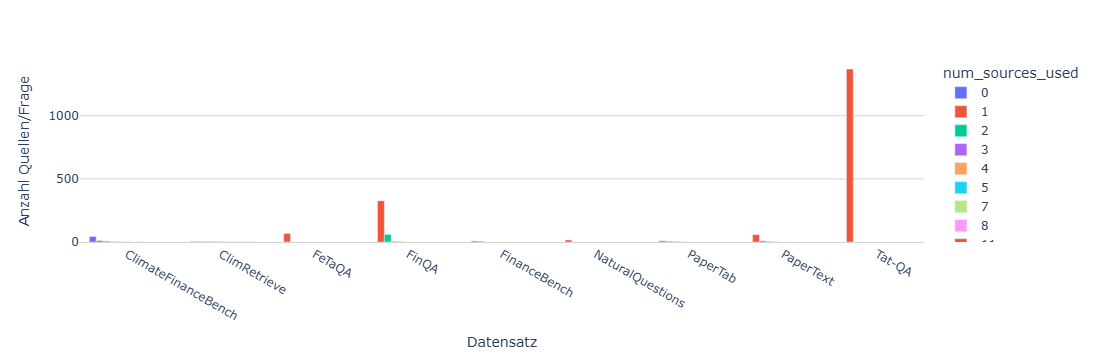

In [22]:
PX.bar(pdfqa_file_path_group_num_sources_used, 
       x='file_path', 
       y='count', 
       color='num_sources_used', 
       barmode='group', 
       category_orders={'num_sources_used': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18']}, 
       xaxes={'title': 'Datensatz'}, 
       yaxes={'title': 'Anzahl Quellen/Frage'})

Die Fragen der Datensätze "FeTaQA", "FinanceBench", "FinQA", "NaturalQuestions", "PaperTab", "PaperText", "Tat-QA" beziehen sich hauptsächlich auf eine bis maximal vier Quellen. 43 der insgesamt 68 Fragen des "ClimateFinanceBench" Datensatzes beziehen sich auf keine Quelle. 50% der Fragen des "ClimRetrieve" Datensatzes beziehen sich auf mehr als 4 Quellen.

### Anzahl Zeichen+Wörter/Frage

Analyse Anzahl Zeichen und Wörter pro Frage

#### Preprocessing

Punctuation entfernen (Muster: r'\p{P}+')

Ein oder mehrfach auftretende Zeilenumbrüche, Tabulatoren oder Leerzeichen durch Leerzeichen ' ' ersetzen (Muster: r'[\n\t\s]+')

In [23]:
# Punctuation entfernen
# Zeilenumbrüche, Tabulatoren und Leerzeichen durch Leerzeichen ersetzen
pdfqa['question_replace'] = pdfqa['question'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
# Anzahl Wörter
pdfqa['question_word_count'] = pdfqa['question_replace'].str.split(' ').str.len()
# Anzahl Zeichen
pdfqa['question_len'] = pdfqa['question'].str.len()

# Anzahl eindeutiger Wörter
pdfqa['question_word_count_distinct'] = pdfqa['question_replace'].apply(lambda col: len(set(col.split(' '))))
# Verhältnis eindeutiger Wörter zu Gesamtzahl
#pdfqa['question_word_count_distinct_ratio'] = pdfqa['question'].apply(lambda col: len(set(col.split(' ')))) / pdfqa['question'].apply(lambda col: len(col.split(' ')))
pdfqa['question_word_count_distinct_ratio'] = pdfqa['question_word_count_distinct'] / pdfqa['question_word_count']

In [24]:
# Statistische Kennzahlen Anzahl Zeichen, Wörter, Verhältnis eindeutige/Gesamtzahl Wörter
pdfqa[['question_len', 'question_word_count', 'question_word_count_distinct', 'question_word_count_distinct_ratio']].describe()

,question_len,question_word_count,question_word_count_distinct,question_word_count_distinct_ratio
count,2037.0,2037.000000,2037.000000,2037.000000
mean,77.351006,13.256259,12.394207,0.952454
std,33.961046,5.437546,4.162611,0.064379
min,17.0,3.000000,3.000000,0.531915
25%,56.0,10.000000,10.000000,0.916667
50%,71.0,12.000000,12.000000,1.000000
75%,93.0,16.000000,15.000000,1.000000
max,592.0,94.000000,50.000000,1.000000


In [25]:
pdfqa

,question,answer,sources,num_sources_used,file_name,file_path,question_replace,question_word_count,question_len,question_word_count_distinct,question_word_count_distinct_ratio
0,According to the company's Disclosure from FY2...,According to the company's statement for fisca...,[doc1{Governance indicators\nBUSINESS CONDUCT ...,2,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,According to the companys Disclosure from FY20...,15,98,14,0.933333
1,Does the company operate in a high emitting se...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,Does the company operate in a high emitting se...,12,64,12,1.000000
2,What is the company's carbon intensity (in TCO...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,What is the companys carbon intensity in TCO2 ...,28,169,24,0.857143
3,Does the company disclose a Transition Plan fo...,LVMH does not explicitly disclose a formal Tra...,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,Does the company disclose a Transition Plan fo...,15,99,15,1.000000
4,What is the total carbon footprint of the comp...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,What is the total carbon footprint of the comp...,39,210,28,0.717949
...,...,...,...,...,...,...,...,...,...,...,...
2032,How does the Group manage its liquidity requir...,The Group manages its liquidity requirements w...,[104\n\n\n\nNotes to the Consolidated Financia...,1,Woolworths-Limited_2019,Tat-QA,How does the Group manage its liquidity requir...,8,53,8,1.000000
2033,What were the organisations the company purcha...,Greenview EMS,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA,What were the organisations the company purcha...,9,58,8,0.888889
2034,What is the percentage change in goodwill from...,1142.18,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA,What is the percentage change in goodwill from...,11,60,11,1.000000
2035,Which year had the highest Net cash provided b...,2017,[_**Sources and Uses of Cash**_\n\n\n**Years E...,1,zix-corporation_2019,Tat-QA,Which year had the highest Net cash provided b...,10,59,10,1.000000


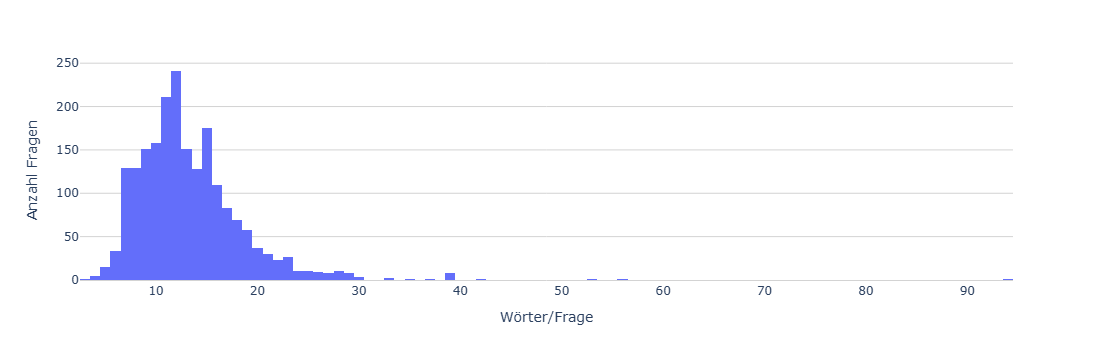

In [26]:
PX.hist(pdfqa['question_word_count'], xaxes = {'title': 'Wörter/Frage'}, yaxes = {'title': 'Anzahl Fragen'})

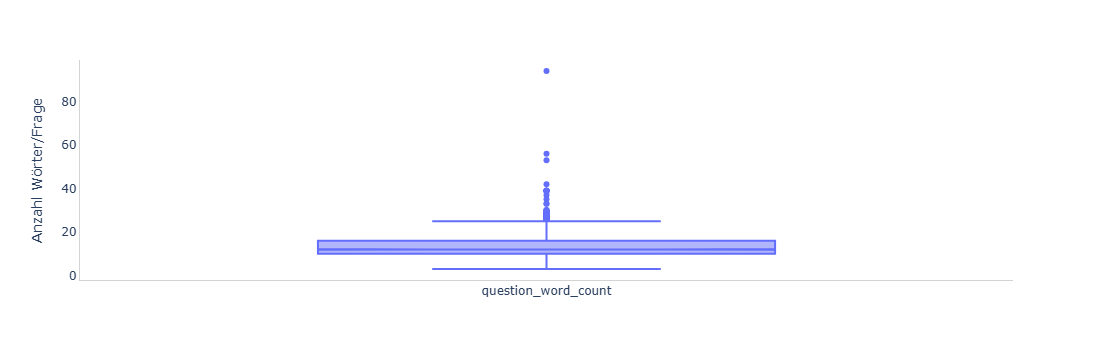

In [27]:
PX.box(pdfqa['question_word_count'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Frage'})

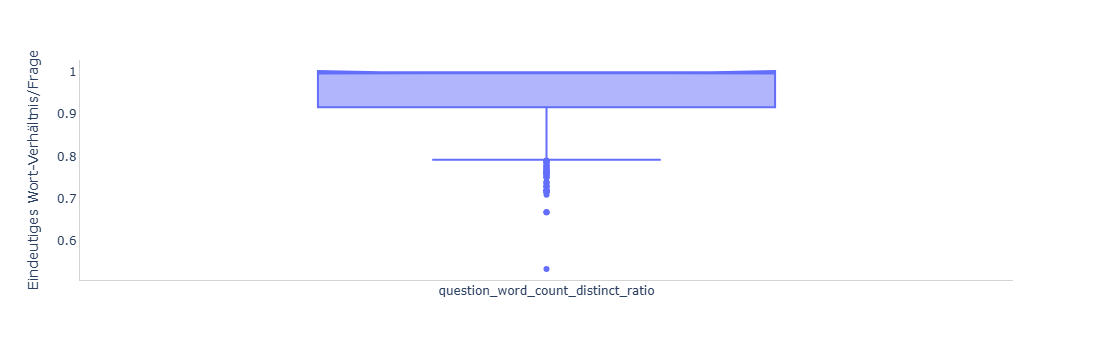

In [28]:
PX.box(pdfqa['question_word_count_distinct_ratio'], xaxes = {'title': ''}, yaxes = {'title': 'Eindeutiges Wort-Verhältnis/Frage'})

In [29]:
# Wort-Anzahl Outlier (Werte größer obere Einzäunung)
pdfqa.loc[pdfqa['question_word_count'] > 25].shape[0]

55

In [30]:
# Beispiel-Fragen mit weniger als 7 Wörtern
pdfqa.loc[pdfqa['question_word_count'] < 7].sample(n=5, axis=0, random_state=42)['question']

645                          Is the model evaluated?
1841         What does services revenue comprise of?
1804               What are total long-lived assets?
622     What text classification task is considered?
1505             What do contract assets consist of?
Name: question, dtype: string

Im Durchschnitt bestehen alle Fragen des Datensatzes aus weniger als 14 Wörtern, 50\% der insgesamt 2037 Fragen haben 12 oder weniger Wörter. 62 Fragen liegen über der oberen Einzäunung von 25 Wörtern und weichen stark von der Verteilung ab, im Maximum besteht eine Frage aus 94 Wörtern. 

Eine Stichprobe zeigt, dass Fragen mit weniger als 7 Wörtern in Teilen sehr allgemein und ohne genauen Kontext formuliert sind.

| Index | question |
| - | - |
|645 | Is the model evaluated? |
|1841 | What does services revenue comprise of? |
|1804 | What are total long-lived assets? |
|622 | What text classification task is considered? |
|1505 | What do contract assets consist of? |

#### Anzahl Wörter/Frage/Datensatz

Anzahl Wörter pro Frage bezogen auf die Datensätze 

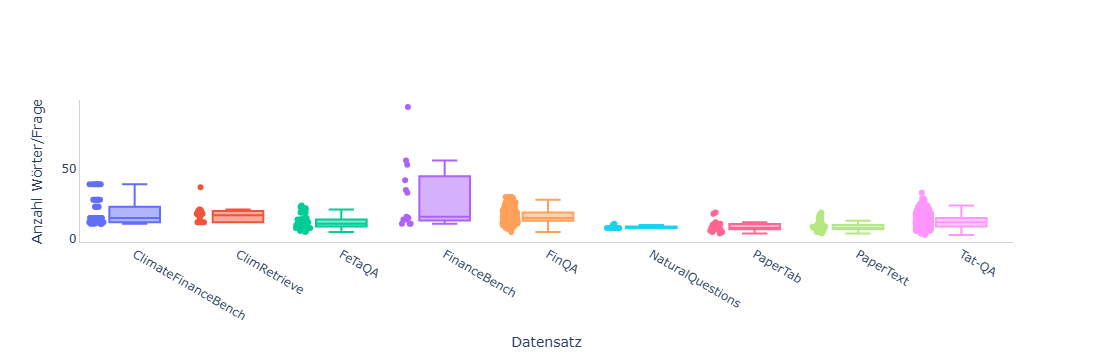

In [31]:
PX.box_multi(pdfqa, 'file_path', 'question_word_count', xaxes = {'title': 'Datensatz'}, yaxes = {'title': 'Anzahl Wörter/Frage'})

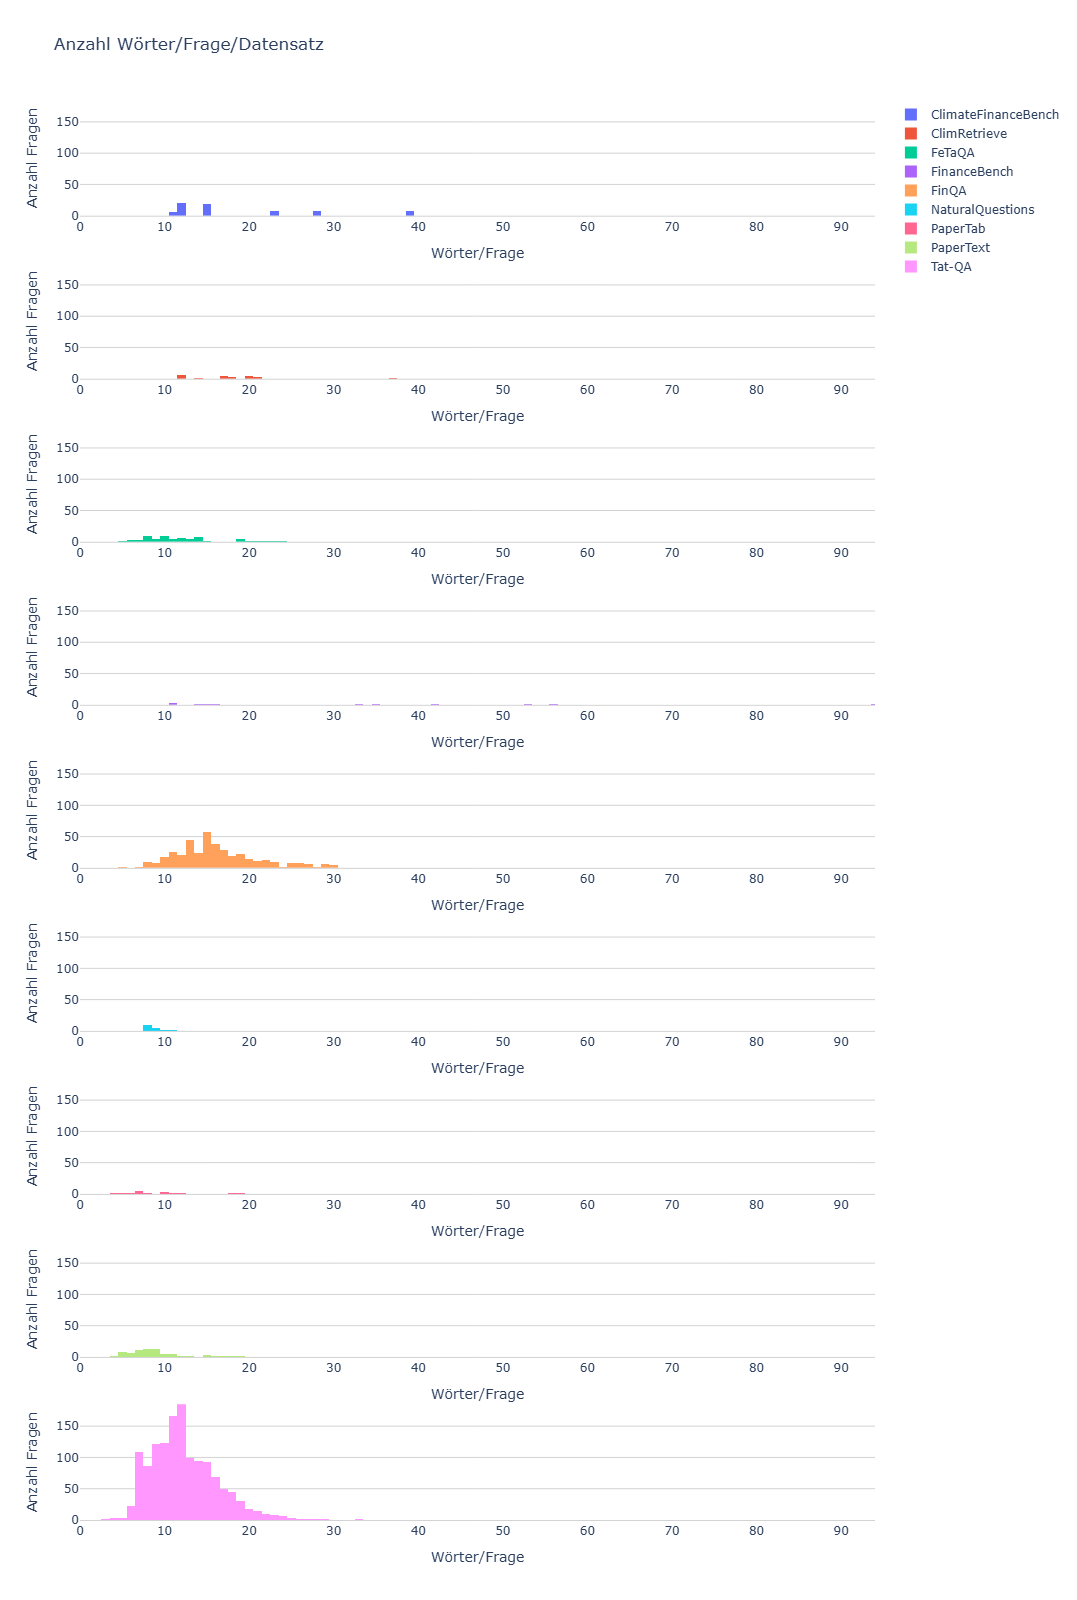

In [32]:
PX.hist_multi(pdfqa, 'file_path', 'question_word_count', xaxes={'title':'Wörter/Frage'}, yaxes={'title':'Anzahl Fragen'}, title='Anzahl Wörter/Frage/Datensatz')

### Anzahl Zeichen+Wörter/Antwort

Analyse Anzahl Zeichen und Wörter pro Antwort

In [33]:
# Punctuation entfernen
# Zeilenumbrüche, Tabulatoren und Leerzeichen durch Leerzeichen ersetzen
pdfqa['answer_replace'] = pdfqa['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
# Anzahl Wörter
pdfqa['answer_word_count'] = pdfqa['answer_replace'].str.split(' ').str.len()
# Anzahl Zeichen
pdfqa['answer_len'] = pdfqa['answer_replace'].str.len()

# Anzahl eindeutiger Wörter
pdfqa['answer_word_count_distinct'] = pdfqa['answer_replace'].apply(lambda col: len(set(col.split(' '))))

#pdfqa['answer_word_count_distinct_ratio'] = pdfqa['answer'].apply(lambda col: len(set(col.split(' ')))) / pdfqa['answer'].apply(lambda col: len(col.split(' ')))
pdfqa['answer_word_count_distinct_ratio'] = pdfqa['answer_word_count_distinct'] / pdfqa['answer_word_count']

In [34]:
pdfqa

,question,answer,sources,num_sources_used,file_name,file_path,question_replace,question_word_count,question_len,question_word_count_distinct,question_word_count_distinct_ratio,answer_replace,answer_word_count,answer_len,answer_word_count_distinct,answer_word_count_distinct_ratio
0,According to the company's Disclosure from FY2...,According to the company's statement for fisca...,[doc1{Governance indicators\nBUSINESS CONDUCT ...,2,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,According to the companys Disclosure from FY20...,15,98,14,0.933333,According to the companys statement for fiscal...,46,355,40,0.869565
1,Does the company operate in a high emitting se...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,Does the company operate in a high emitting se...,12,64,12,1.000000,Not available in the retrieved information,6,42,6,1.000000
2,What is the company's carbon intensity (in TCO...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,What is the companys carbon intensity in TCO2 ...,28,169,24,0.857143,Not available in the retrieved information,6,42,6,1.000000
3,Does the company disclose a Transition Plan fo...,LVMH does not explicitly disclose a formal Tra...,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,Does the company disclose a Transition Plan fo...,15,99,15,1.000000,LVMH does not explicitly disclose a formal Tra...,42,306,40,0.952381
4,What is the total carbon footprint of the comp...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,What is the total carbon footprint of the comp...,39,210,28,0.717949,Not available in the retrieved information,6,42,6,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,How does the Group manage its liquidity requir...,The Group manages its liquidity requirements w...,[104\n\n\n\nNotes to the Consolidated Financia...,1,Woolworths-Limited_2019,Tat-QA,How does the Group manage its liquidity requir...,8,53,8,1.000000,The Group manages its liquidity requirements w...,23,154,21,0.913043
2033,What were the organisations the company purcha...,Greenview EMS,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA,What were the organisations the company purcha...,9,58,8,0.888889,Greenview EMS,2,13,2,1.000000
2034,What is the percentage change in goodwill from...,1142.18,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA,What is the percentage change in goodwill from...,11,60,11,1.000000,114218,1,6,1,1.000000
2035,Which year had the highest Net cash provided b...,2017,[_**Sources and Uses of Cash**_\n\n\n**Years E...,1,zix-corporation_2019,Tat-QA,Which year had the highest Net cash provided b...,10,59,10,1.000000,2017,1,4,1,1.000000


In [35]:
# Statistische Kennzahlen Anzahl Zeichen, Wörter, Verhältnis eindeutige/Gesamtzahl Wörter
pdfqa[['answer_len', 'answer_word_count', 'answer_word_count_distinct', 'answer_word_count_distinct_ratio']].describe()

,answer_len,answer_word_count,answer_word_count_distinct,answer_word_count_distinct_ratio
count,2037.0,2037.000000,2037.000000,2037.000000
mean,27.201276,4.529701,3.972018,0.983127
std,80.799606,11.687765,9.157630,0.056867
min,1.0,1.000000,1.000000,0.562500
25%,3.0,1.000000,1.000000,1.000000
50%,4.0,1.000000,1.000000,1.000000
75%,7.0,1.000000,1.000000,1.000000
max,1242.0,181.000000,126.000000,1.000000


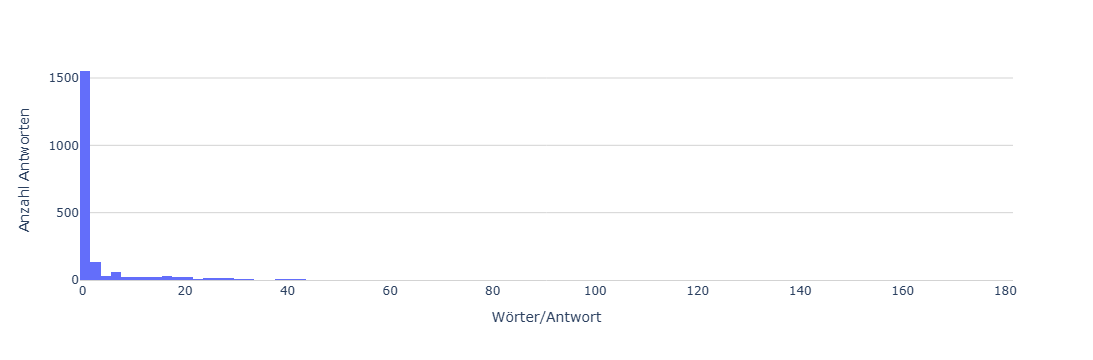

In [36]:
PX.hist(pdfqa['answer_word_count'], xaxes = {'title': 'Wörter/Antwort'}, yaxes = {'title': 'Anzahl Antworten'})

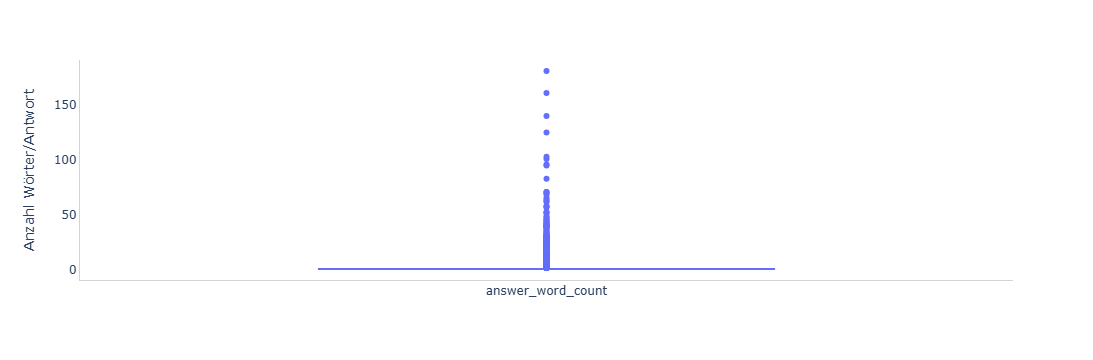

In [37]:
PX.box(pdfqa['answer_word_count'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Antwort'})

In [38]:
# Wort-Anzahl Outlier (Werte über oberer Einzäunung)
pdfqa.loc[pdfqa['answer_word_count'] > 1].shape[0]

485

In [39]:
# Absolute Häufigkeit Antworten mit einem Wort (Top-Ten)
pdfqa.loc[pdfqa['answer_word_count'] == 1, 'answer'].value_counts().reset_index().iloc[:10]

,answer,count
0,2,33
1,no,24
2,1,22
3,2019,20
4,2018,15
5,No,13
6,3,9
7,2017,7
8,18%,5
9,41%,4


In [40]:
# Absolute Häufigkeit Antworten mit weniger als 8 Wörtern (Top-Ten)
pdfqa.loc[pdfqa['answer_word_count'] < 8, 'answer'].value_counts().reset_index().iloc[:10]

,answer,count
0,2,33
1,Not available in the retrieved information.,28
2,no,24
3,1,22
4,2019,20
5,2018,15
6,No,13
7,Not available in the retrieved information,12
8,3,9
9,2017,7


Im Durchschnitt bestehen die Antworten aus weniger als 5 Wörtern und die Standardabweichung ist mit 11.7 relativ hoch. 1552 der insgesamt 2037 Antworten, ca. 76\%, bestehen aus nur einem Wort. 1770 der Fragen, ca. 86,9\%, haben weniger als 8 Wörter und sind damit immernoch sehr kurz. Das Verhätnis der eindeutigen Wörter gegenüber der Gesamtzahl ist mit durchschnittlich 0.983 hoch und die Standardabweichung mit 0.057 gering. Die Antworten besitzen ein hohe Wort-Vielfalt

#### Antworten mit Anzahl Wörtern>=8

Anzahl der Fragen pro Datensatz mit mindestens 8 Wörtern.

In [41]:
# Antworten mit 8 oder mehr Wörtern selektieren
pdfqa_answer_word_count = pdfqa.loc[pdfqa['answer_word_count'] >= 8]

# Anzahl Antworten pro Datensatz
pdfqa_answer_word_count_file_path_value_counts = pdfqa_answer_word_count['file_path'].value_counts()

print(pdfqa_answer_word_count_file_path_value_counts)

file_path
Tat-QA                 124
FeTaQA                  67
PaperText               33
ClimateFinanceBench     26
PaperTab                 9
FinanceBench             7
FinQA                    1
Name: count, dtype: int64[pyarrow]


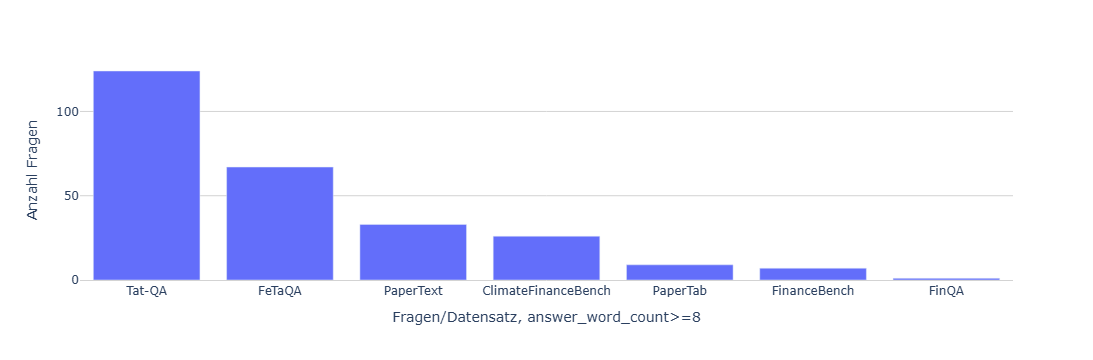

In [42]:
PX.bar(pd.DataFrame({'x': pdfqa_answer_word_count_file_path_value_counts.index.tolist(), 'y': pdfqa_answer_word_count_file_path_value_counts.values.tolist()}), xaxes = {'title': 'Fragen/Datensatz, answer_word_count>=8'}, yaxes = {'title': 'Anzahl Fragen'})

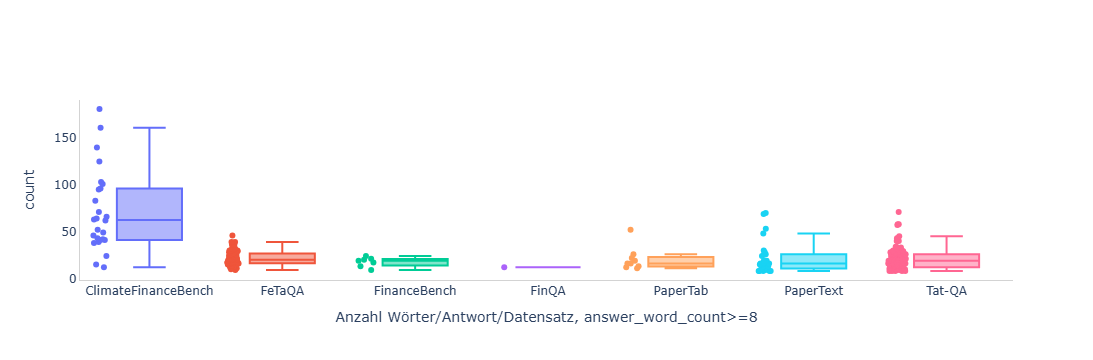

In [43]:
PX.box_multi(pdfqa_answer_word_count, 'file_path', 'answer_word_count', xaxes = {'title': 'Anzahl Wörter/Antwort/Datensatz, answer_word_count>=8'}, yaxes = {'title': 'count'})

In [44]:
# Durchschnittliches Verhältnis eindeutiger zu Gesamtzahl Wörter für Fragen+Antworten
pdfqa_answer_word_count[['question_word_count_distinct_ratio', 'answer_word_count_distinct_ratio']].mean()

question_word_count_distinct_ratio    0.966058
answer_word_count_distinct_ratio      0.878080
dtype: float64

In [45]:
pdfqa_answer_word_count.loc[pdfqa_answer_word_count['file_path'] == 'PaperTab', ['answer']]#FinQA#NaturalQuestions
#pdfqa.loc[pdfqa['file_path'] == 'NaturalQuestions', 'answer']

,answer
578,0.8 points on Binary; 0.7 points on Fine-Grain...
581,Their average improvement in Character Error R...
582,Accuracy on each dataset and the average accur...
585,"SemEval 2018 Task 3, BIBREF20, BIBREF4, SARC 2..."
590,"EN, JA, ES, AR, PT, KO, TH, FR, TR, RU, IT, DE..."
591,In-house dataset consists of 3716 documents \...
592,Proposed SG model vs SINDHI FASTTEXT:\nAverage...
595,"Alarm, Banks, Buses, Calendar, Events, Flights..."
596,Transcribed data is available for duration of ...


#### Anzahl Wörter/Antwort/Datensatz

Anzahl der Wörter pro Antwort für Datensätze

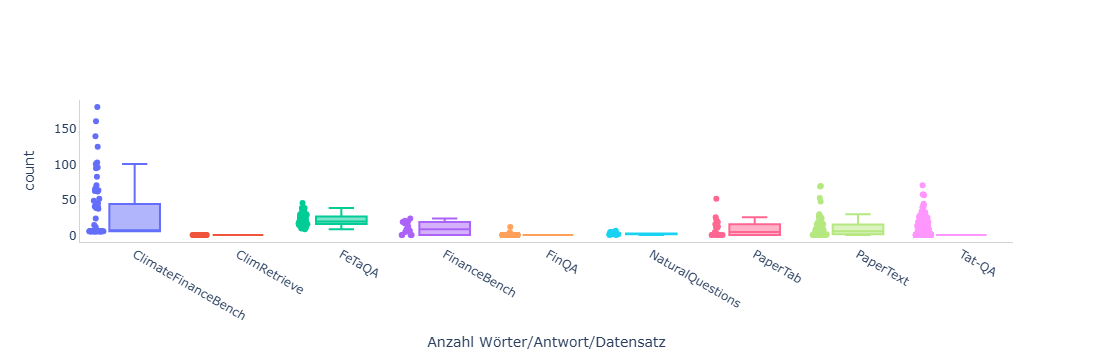

In [46]:
PX.box_multi(pdfqa, 'file_path', 'answer_word_count', xaxes = {'title': 'Anzahl Wörter/Antwort/Datensatz'}, yaxes = {'title': 'count'})

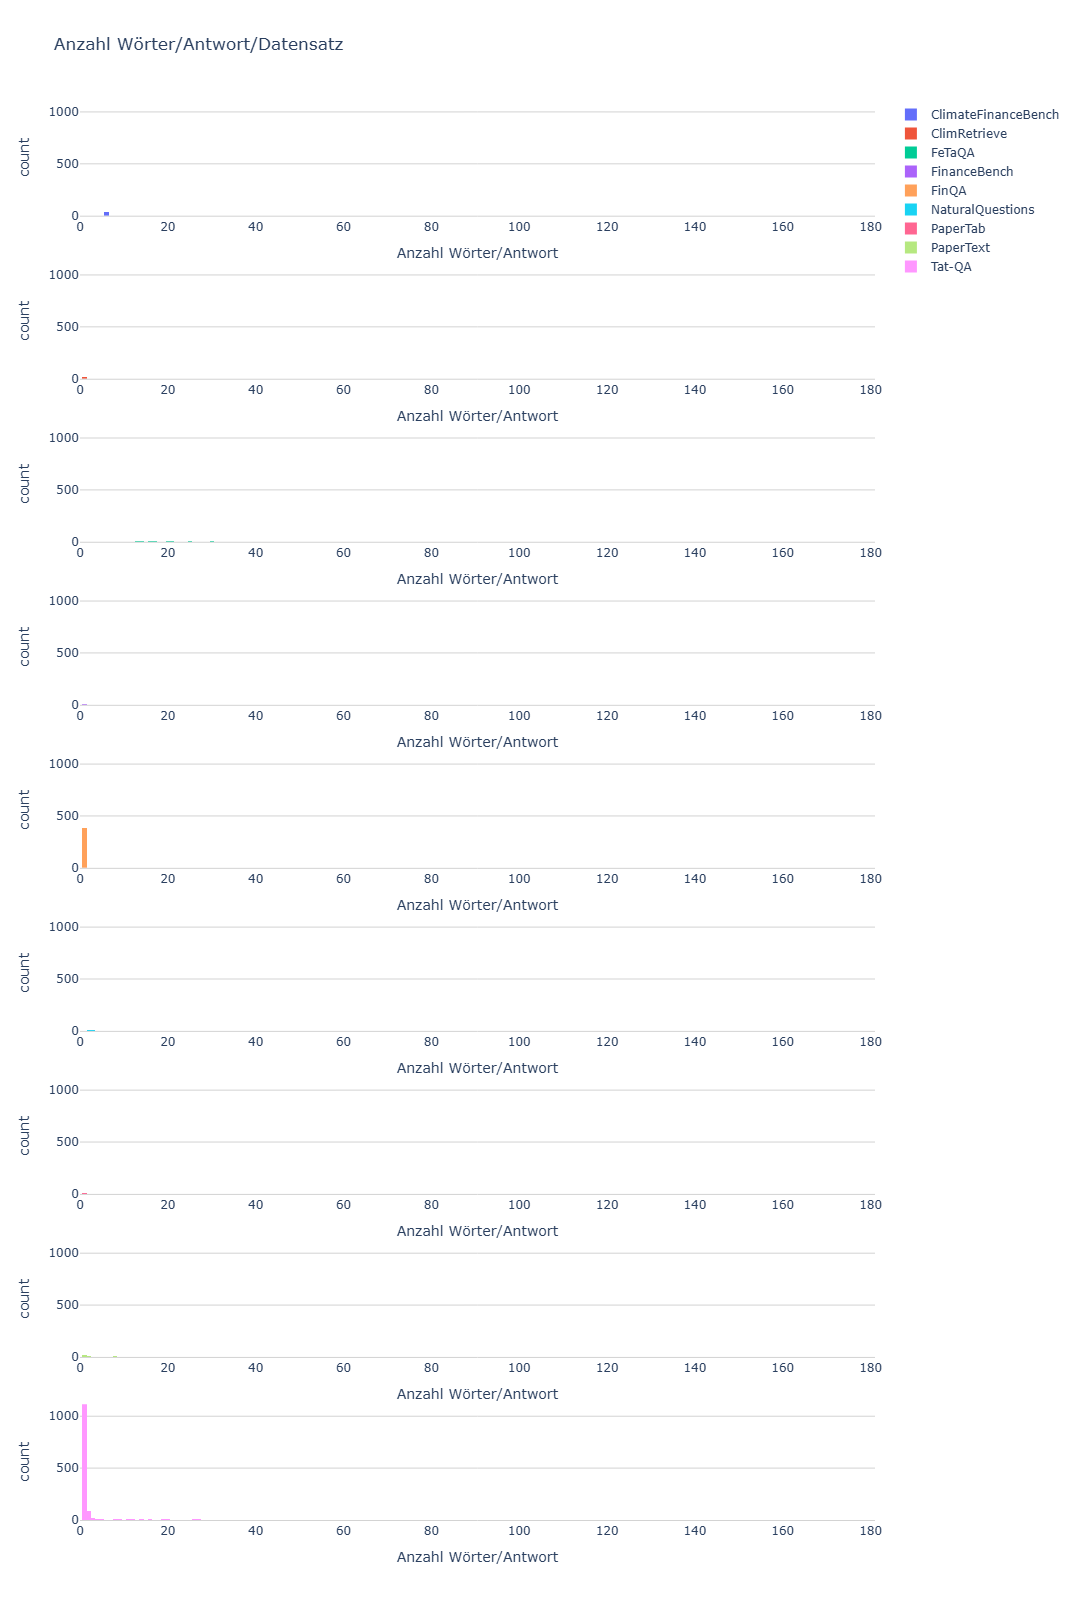

In [47]:
PX.hist_multi(pdfqa, 'file_path', 'answer_word_count', xaxes={'title':'Anzahl Wörter/Antwort'}, yaxes={'title':'count'}, title='Anzahl Wörter/Antwort/Datensatz')

### Dokumente/Abschnitte

Analyse der Dokumente/Abschnitte

In [48]:
#pdfqa['file_name'].unique().shape[0]

#### Anzahl Zeichen+Wörter/Abschnitte

Analyse Anzahl Zeichen und Wörter pro Antwort

In [49]:
# Liste in String umwandeln
pdfqa['sources_str'] = pdfqa["sources"].str[0]
pdfqa = pdfqa.astype({'sources_str': 'string'})
# NA-Werte durch leere Zeichenkette ersetzen
pdfqa.loc[pdfqa['sources_str'].isna(), 'sources_str'] = ''

pdfqa['sources_str'] = (
    pdfqa['sources_str'].str.replace(r'^doc1\{', '', regex=True)
    .str.replace(r'\}$', '', regex=True)
)

# Punctuation entfernen
# Zeilenumbrüche, Tabulatoren und Leerzeichen durch Leerzeichen ersetzen
pdfqa['sources_str_replace'] = (
    pdfqa['sources_str'].str.replace(r'\p{P}+', '', regex=True)
    .str.replace(r'[\n\t\s]+', ' ', regex=True)
)

# Anzahl Wörter
#pdfqa['sources_len'] = pdfqa["sources"].str[0].str.split(' ').str.len()
pdfqa['sources_word_count'] = pdfqa['sources_str_replace'].str.split(' ').str.len()
# Anzahl Zeichen
pdfqa['sources_len'] = pdfqa['sources_str'].str.len()

# Anzahl eindeutiger Wörter
pdfqa['sources_word_count_distinct'] = pdfqa['sources_str_replace'].apply(lambda col: len(set(col.split(' '))))
# Verhältnis eindeutiger Wörter zu Gesamtzahl
pdfqa['sources_word_count_distinct_ratio'] = pdfqa['sources_word_count_distinct'] / pdfqa['sources_word_count']

In [50]:
pdfqa

,question,answer,sources,num_sources_used,file_name,file_path,question_replace,question_word_count,question_len,question_word_count_distinct,...,answer_word_count,answer_len,answer_word_count_distinct,answer_word_count_distinct_ratio,sources_str,sources_str_replace,sources_word_count,sources_len,sources_word_count_distinct,sources_word_count_distinct_ratio
0,According to the company's Disclosure from FY2...,According to the company's statement for fisca...,[doc1{Governance indicators\nBUSINESS CONDUCT ...,2,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,According to the companys Disclosure from FY20...,15,98,14,...,46,355,40,0.869565,Governance indicators\nBUSINESS CONDUCT \n◆ Et...,Governance indicators BUSINESS CONDUCT ◆ Ethic...,418,2788,285,0.681818
1,Does the company operate in a high emitting se...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,Does the company operate in a high emitting se...,12,64,12,...,6,42,6,1.000000,,,1,0,1,1.000000
2,What is the company's carbon intensity (in TCO...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,What is the companys carbon intensity in TCO2 ...,28,169,24,...,6,42,6,1.000000,,,1,0,1,1.000000
3,Does the company disclose a Transition Plan fo...,LVMH does not explicitly disclose a formal Tra...,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,Does the company disclose a Transition Plan fo...,15,99,15,...,42,306,40,0.952381,,,1,0,1,1.000000
4,What is the total carbon footprint of the comp...,Not available in the retrieved information.,[doc1{}],0,015157_LVMH_RSE_committed_to_positive_impact_2...,ClimateFinanceBench,What is the total carbon footprint of the comp...,39,210,28,...,6,42,6,1.000000,,,1,0,1,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2032,How does the Group manage its liquidity requir...,The Group manages its liquidity requirements w...,[104\n\n\n\nNotes to the Consolidated Financia...,1,Woolworths-Limited_2019,Tat-QA,How does the Group manage its liquidity requir...,8,53,8,...,23,154,21,0.913043,104\n\n\n\nNotes to the Consolidated Financial...,104 Notes to the Consolidated Financial Statem...,360,2447,199,0.552778
2033,What were the organisations the company purcha...,Greenview EMS,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA,What were the organisations the company purcha...,9,58,8,...,2,13,2,1.000000,"**December 31,**\n**(In thousands)** **Balance...",December 31 In thousands Balance Sheet Classif...,275,2274,167,0.607273
2034,What is the percentage change in goodwill from...,1142.18,"[**December 31,**\n**(In thousands)** **Balanc...",1,zix-corporation_2019,Tat-QA,What is the percentage change in goodwill from...,11,60,11,...,1,6,1,1.000000,"**December 31,**\n**(In thousands)** **Balance...",December 31 In thousands Balance Sheet Classif...,275,2274,167,0.607273
2035,Which year had the highest Net cash provided b...,2017,[_**Sources and Uses of Cash**_\n\n\n**Years E...,1,zix-corporation_2019,Tat-QA,Which year had the highest Net cash provided b...,10,59,10,...,1,4,1,1.000000,_**Sources and Uses of Cash**_\n\n\n**Years En...,Sources and Uses of Cash Years Ended December ...,619,4205,260,0.420032


In [51]:
pdfqa.loc[pdfqa['sources_len'] > 0, ['sources_len', 'sources_word_count', 'sources_word_count_distinct', 'sources_word_count_distinct_ratio']].describe()

,sources_len,sources_word_count,sources_word_count_distinct,sources_word_count_distinct_ratio
count,1995.0,1995.000000,1995.000000,1995.000000
mean,2767.251629,399.647118,179.675689,0.498810
std,2054.25959,291.905882,114.111731,0.135373
min,46.0,6.000000,6.000000,0.139303
25%,658.0,118.000000,60.000000,0.416935
50%,2802.0,389.000000,190.000000,0.467875
75%,3889.0,552.500000,249.000000,0.538941
max,10373.0,1559.000000,570.000000,1.000000


### Tat-QA

Analyse der Daten in Bezug auf den Tat-QA Datensatz

In [52]:
pdfqa_tat_qa = pdfqa.loc[pdfqa['file_path'] == 'Tat-QA']

In [53]:
print(f'Anzahl Fragen: {pdfqa_tat_qa.shape[0]}')
print(f'Anzahl Worte/Antwort==1: {pdfqa_tat_qa.loc[pdfqa_tat_qa["answer_word_count"] == 1].shape[0]}')

Anzahl Fragen: 1369
Anzahl Worte/Antwort==1: 1115


1115 der Antworten zu den insgesamt 1369 Fragen des Datensatzes, ca. 81,4%, enhalten lediglich ein Wort.

#### Anzahl Quellen/Frage

In [54]:
pdfqa_tat_qa_num_sources_used_value_counts = pdfqa.loc[pdfqa['file_path'] == 'Tat-QA']['num_sources_used'].value_counts()
print(pdfqa_tat_qa_num_sources_used_value_counts)

num_sources_used
1    1369
Name: count, dtype: Int64


#### Anzahl Zeichen/Wörter Frage

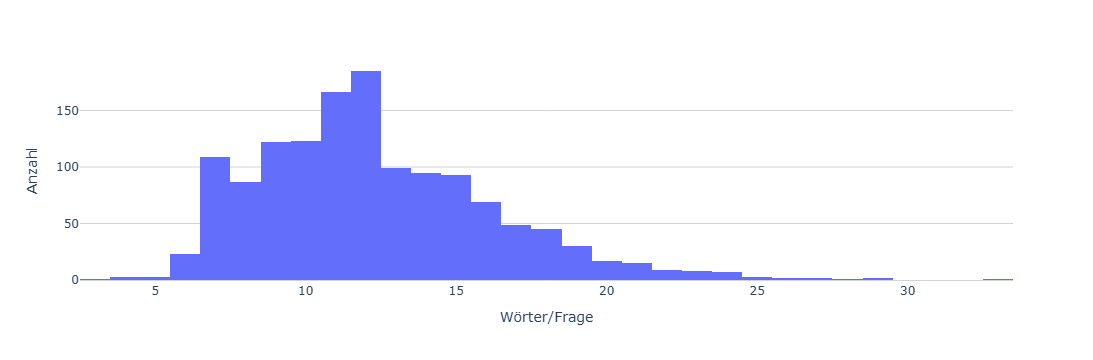

In [55]:
PX.hist(pdfqa_tat_qa['question_word_count'], xaxes = {'title': 'Wörter/Frage'}, yaxes = {'title': 'Anzahl'})

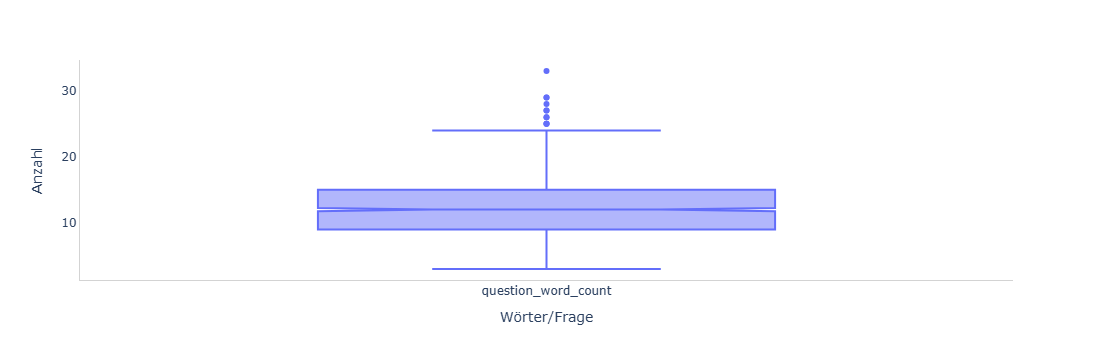

In [56]:
PX.box(pdfqa_tat_qa['question_word_count'], xaxes = {'title': 'Wörter/Frage'}, yaxes = {'title': 'Anzahl'})

#### Anzahl Zeichen/Wörter Antwort

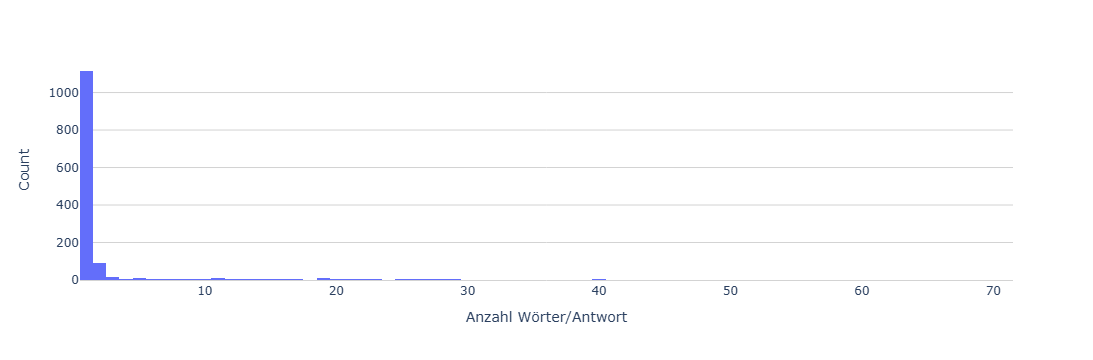

In [57]:
PX.hist(pdfqa_tat_qa['answer_word_count'], xaxes = {'title': 'Anzahl Wörter/Antwort'}, yaxes = {'title': 'Count'})

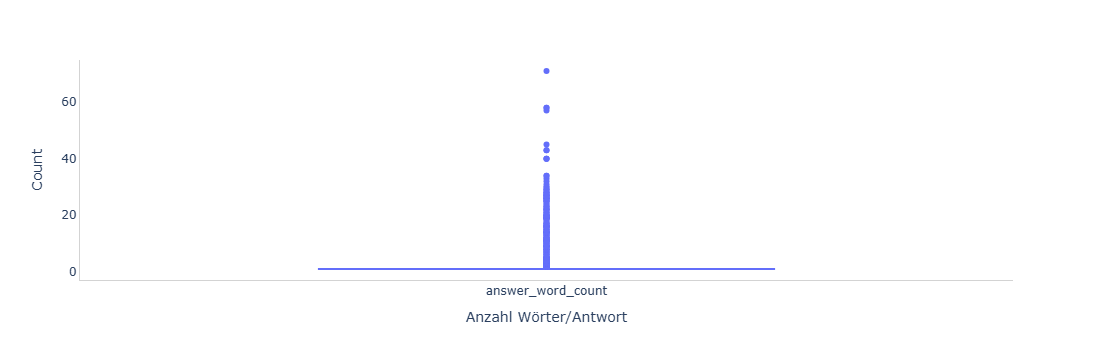

In [58]:
PX.box(pdfqa_tat_qa['answer_word_count'], xaxes = {'title': 'Anzahl Wörter/Antwort'}, yaxes = {'title': 'Count'})

### Sample

Ausgabe der Frage, Antwort und Quelle für ein Beispiel

In [59]:
index = 0

print('question\n')
print(pdfqa.iloc[index]['question'])
print('\n---answer\n')
print(pdfqa.iloc[index]['answer'])
print('\n---sources\n')
print(pdfqa.iloc[index]['sources'])

question

According to the company's Disclosure from FY2023, which topics have been assessed to be material?

---answer

According to the company's statement for fiscal 2023, the following topics are considered material: 
Environmental indicators:
-CLIMATE CHANGE 
-POLLUTION
-WATER AND MARINE RESOURCES
-BIODIVERSITY AND ECOSYSTEMS
-RESOURCES USE AND CIRCULAR ECONOMY

Social indicators: 
-OWN WORKFORCE
-WORKERS IN THE VALUE CHAIN
-AFFECTED COMMUNITIES

Governance indicators:
-BUSINESS CONDUCT

---sources

['doc1{Governance indicators\nBUSINESS CONDUCT \n◆ Ethical principles fleshed out and circulated more widely: update to the LVMH Code of Conduct and the Supplier and Commercial Partner Code of Conduct\n◆ Program expanded: publication of the Anti-Corruption Charter and the Responsible Lobbying Charter \n561concerns raised via the LVMH Alert Line\nSocial indicators \nOWN WORKFORCE\n46% of key positions held by women\n1.6% of the workforce  have disabilities\n82% of recruiters underwent n

#### Strukturierte Dokument-Daten zu Frage/Antwort

In [60]:
index = 0
file_full = f'https://huggingface.co/datasets/pdfqa/pdfQA-Benchmark/resolve/main/real-pdfQA/01.3_Input_Files_CSV/{pdfqa.iloc[index]['file_path']}/{urllib.parse.quote(pdfqa.iloc[index]['file_name'])}__pymupdf.csv?download=true'

# CSV-Datei einlesen
pdfqa_file = pd.read_csv(file_full, sep=',')

pdfqa_file

# URL
#https://huggingface.co/datasets/pdfqa/pdfQA-Benchmark/resolve/main/real-pdfQA/01.3_Input_Files_CSV/ClimateFinanceBench/015157_LVMH_RSE_committed_to_positive_impact_2023_GB_SR_MEL_080724%20(6)_2024-09-19_10_56__pymupdf.csv?download=true
#https://huggingface.co/datasets/pdfqa/pdfQA-Benchmark/resolve/main/real-pdfQA/01.2_Input_Files_PDF/ClimateFinanceBench/015157_LVMH_RSE_committed_to_positive_impact_2023_GB_SR_MEL_080724%20(6)_2024-09-19_10_56.pdf?download=true
#https://huggingface.co/datasets/pdfqa/pdfQA-Benchmark/resolve/main/real-pdfQA/01.1_Input_Files_Non_PDF/ClimateFinanceBench/015157_LVMH_RSE_committed_to_positive_impact_2023_GB_SR_MEL_080724%20(6)_2024-09-19_10_56__pymupdf.txt?download=true

,content,file_name,source_identifier
0,2 0 2 3 S O C I A L A N D E N V I R O N M E...,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_0
1,NaN,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_1
2,Committed \nto positive \n impact,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_2
3,NaN,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_3
4,"The year in brief\nAt LVMH, we know that unfai...",015157_LVMH_RSE_committed_to_positive_impact_2...,Source_4
...,...,...,...
327,77: ©Boby et ©Philippe Servent – p. 81: ©Stéph...,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_327
328,110: DR Loro Piana – p. 111: Loro Piana – The ...,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_328
329,: 33 (0)1 44 13 22 22 – www.lvmh.com\nsocial.r...,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_329
330,NaN,015157_LVMH_RSE_committed_to_positive_impact_2...,Source_330
